In [28]:
import matplotlib.pyplot as plt
from OptimalBattery.global_config import repo_dir,save_dir
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib.patches import Patch
import matplotlib as mpl
mpl.rcParams["pdf.fonttype"] = 3
from scipy.stats import pearsonr
from scipy.stats import sem
from scipy.stats import ttest_rel
from matplotlib.patches import Patch
from scipy.stats import gamma as gamma_dist



# simulations

In [21]:
sim_df = pd.read_csv(f"{repo_dir}/eval_tsvs/localization_sim_results.tsv", sep="\t")
# pick a random 100 individuals
unique_ids = sim_df['individual'].unique()
rng = np.random.default_rng(0)
picked_ids = rng.choice(unique_ids, size=1000, replace=False)
sim_df = sim_df[sim_df['individual'].isin(picked_ids)]
sim_df = sim_df[sim_df['snr_factor'] < 0.035]


In [22]:
palette = {
    "multitask": "#A34700",              
    "contrast_fixed": "#005788",        
    "contrast_adaptive": "#007656" 
}

In [23]:
df_multi = sim_df[sim_df["type"] == "multitask"]
df_contrast = sim_df[sim_df["type"] == "contrast_fixed"]

r_multi, p_multi = pearsonr(df_multi["predicted_size"], df_multi["snr_factor"])
r_contrast, p_contrast = pearsonr(df_contrast["predicted_size"], df_contrast["snr_factor"])



print("Multi-task localizer:")
print(f"  r = {r_multi:.3f}, p = {p_multi:.3e}")

print("Single-contrast (T) localizer:")
print(f"  r = {r_contrast:.3f}, p = {p_contrast:.3e}")


Multi-task localizer:
  r = 0.004, p = 9.067e-01
Single-contrast (T) localizer:
  r = 0.414, p = 1.225e-41


In [24]:
sub_mean = sim_df.groupby("individual")["accuracy"].transform("mean")
global_mean = sim_df["accuracy"].mean()
sim_df["accuracy_adj"] = sim_df["accuracy"] - sub_mean + global_mean

In [25]:
acc_single_fixed = sim_df[sim_df["type"] == "contrast_fixed"]["accuracy_adj"]
acc_multi  = sim_df[sim_df["type"] == "multitask"]["accuracy_adj"]
acc_single_adaptive  = sim_df[sim_df["type"] == "contrast_adaptive"]["accuracy_adj"]

In [26]:
tval, pval = ttest_rel(acc_multi, acc_single_fixed)
print("t =", tval, "   p =", pval)
tval, pval = ttest_rel(acc_multi, acc_single_adaptive)
print("t =", tval, "   p =", pval)

t = 18.359118608784605    p = 7.042051012458212e-65
t = 51.95324249013715    p = 5.361514039071284e-283


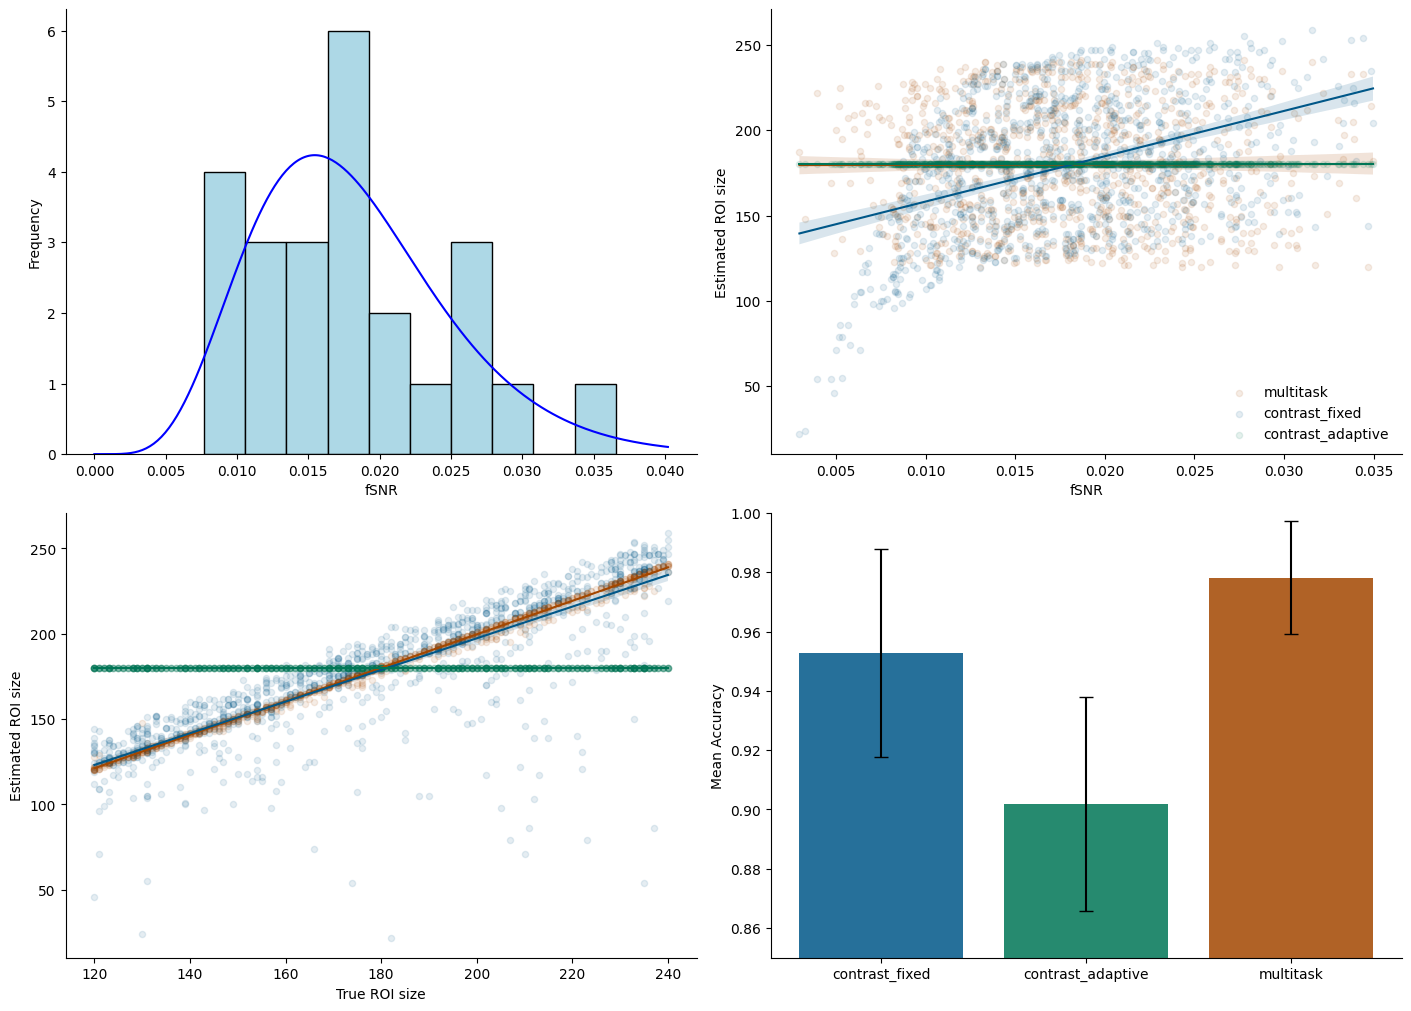

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10),constrained_layout=True)
# Panel a (top-left): empirical fSNR distribution
ax = axes[0, 0]
snr_list = [0.0196991187488852, 0.0291119097017132, 0.009868315372056239, 0.02666920728512233, 0.012530722513964174,
0.023969897215134296, 0.026436919129805385, 0.019008834666825788, 0.014048736255142842, 0.018222607813836222,
0.03655696258923394, 0.00945854991438873, 0.017826522554411507, 0.016721016465301754, 0.01134745499645742,
0.027609353003180823, 0.019002938368900588, 0.014779159602009994, 0.019332472019233885, 0.012547128382596882,
0.015449975415808167, 0.017610806336780898, 0.009659853650544005, 0.007693769241799343]
shape, loc, scale = gamma_dist.fit(snr_list, floc=0)
ax.hist(snr_list, bins=10, color="lightblue", edgecolor="black")
x = np.linspace(0, max(snr_list)*1.1, 300)
pdf = gamma_dist.pdf(x, shape, loc=loc, scale=scale)
bin_width = (max(snr_list) - min(snr_list)) / 10
ax.plot(x, pdf * len(snr_list) * bin_width, color="blue")
ax.set_xlabel("fSNR")
ax.set_ylabel("Frequency")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Panel b (top-right): fSNR vs estimated ROI size
ax = axes[0, 1]
for type_name, color in palette.items():
    subset = sim_df[sim_df['type'] == type_name]
    ax.scatter(subset["snr_factor"], subset["predicted_size"], c=color, s=20, alpha=0.1, rasterized=True,
label=type_name)
    sns.regplot(data=subset, x="snr_factor", y="predicted_size", scatter=False, color=color, line_kws={'linewidth':
1.5}, ax=ax)
ax.set_xlabel("fSNR")
ax.set_ylabel("Estimated ROI size")
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Panel c (bottom-left): true vs estimated ROI size
ax = axes[1, 0]
for type_name, color in palette.items():
    subset = sim_df[sim_df['type'] == type_name]
    ax.scatter(subset["true_size"], subset["predicted_size"], c=color, s=20, alpha=0.1, rasterized=True)
    sns.regplot(data=subset, x="true_size", y="predicted_size", scatter=False, color=color, line_kws={'linewidth':
1.5}, ax=ax)
ax.set_xlabel("True ROI size")
ax.set_ylabel("Estimated ROI size")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Panel d (bottom-right): accuracy bars
ax = axes[1, 1]
order = ["contrast_fixed", "contrast_adaptive", "multitask"]
means = [sim_df.loc[sim_df["type"] == t, "accuracy_adj"].mean() for t in order]
sds = [sim_df.loc[sim_df["type"] == t, "accuracy_adj"].std(ddof=1) for t in order]
colors_bar = [palette[t] for t in order]
x = np.arange(len(order))
ax.bar(x, means, yerr=sds, capsize=5, color=colors_bar, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(order)
ax.set_ylabel("Mean Accuracy")
ax.set_ylim(0.85, 1.0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.savefig(f"{save_dir}/single_vs_multi/fig2_combined.svg", bbox_inches="tight")
plt.show()

# fMRI

In [46]:
real_df = pd.read_csv(f"{repo_dir}/eval_tsvs/localization_real_contrasts.tsv", sep="\t")


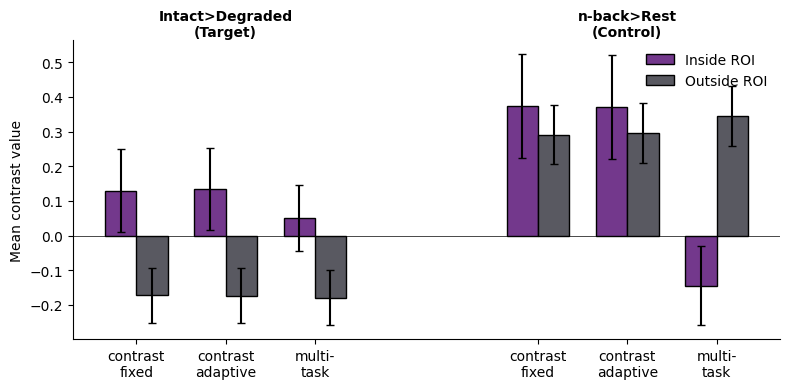

In [47]:
locs = ["contrast_fixed", "contrast_adaptive", "multitask"]
loc_labels = ["contrast\nfixed", "contrast\nadaptive", "multi-\ntask"]
contrasts = ["intact>degraded", "nback>rest"]
regions = ["Inside", "Outside"]

colors = {"Inside": (0.45, 0.22, 0.55), "Outside": (0.35, 0.35, 0.38)}

# reshape into long format 
rows = []
for _, row in real_df.iterrows():
    rows.append([row.localizer, row.contrast, "Inside", row.inside])
    rows.append([row.localizer, row.contrast, "Outside", row.outside])

long_df = pd.DataFrame(rows, columns=["localizer", "contrast", "region", "value"])

# compute mean + SEM
plot_rows = []
for L in locs:
    for R in regions:
        for C in contrasts:
            vals = long_df[
                (long_df.localizer == L) &
                (long_df.region == R) &
                (long_df.contrast == C)
            ]["value"].values

            plot_rows.append([L, R, C,
                np.nanmean(vals),
                sem(vals, nan_policy="omit")
            ])

plot_df = pd.DataFrame(plot_rows, columns=["Loc", "Reg", "Con", "Mean", "SEM"])

# plot
fig, ax = plt.subplots(figsize=(8, 4))

n_locs = len(locs)
n_contrasts = len(contrasts)
w = 0.35  # bar width
loc_spacing = 1.0  # spacing between localizers within a contrast group
group_spacing = 1.5  # extra spacing between the two contrast groups

# Build x positions: group by contrast, then localizer, then region
x_positions = {}
x_tick_positions = []
x_tick_labels = []

current_x = 0
for ci, C in enumerate(contrasts):
    group_start = current_x
    for li, L in enumerate(locs):
        # Inside and Outside bars side by side
        x_positions[(C, L, "Inside")] = current_x
        x_positions[(C, L, "Outside")] = current_x + w
        
        x_tick_positions.append(current_x + w/2)
        x_tick_labels.append(loc_labels[li])
        
        current_x += loc_spacing
    
    # Add group spacing after first contrast group
    if ci < n_contrasts - 1:
        current_x += group_spacing

# Plot bars
for C in contrasts:
    for L in locs:
        for R in regions:
            sub = plot_df[(plot_df.Loc == L) & (plot_df.Reg == R) & (plot_df.Con == C)]
            ax.bar(
                x_positions[(C, L, R)],
                sub["Mean"].values[0],
                w,
                color=colors[R],
                edgecolor="black",
                yerr=sub["SEM"].values[0],
                capsize=3
            )

# Add contrast group labels at top
group1_center = np.mean([x_positions[("intact>degraded", L, "Inside")] + w/2 for L in locs])
group2_center = np.mean([x_positions[("nback>rest", L, "Inside")] + w/2 for L in locs])

ymax = ax.get_ylim()[1]
ax.text(group1_center, ymax * 1.02, "Intact>Degraded\n(Target)", ha='center', fontsize=10, fontweight='bold')
ax.text(group2_center, ymax * 1.02, "n-back>Rest\n(Control)", ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(x_tick_positions)
ax.set_xticklabels(x_tick_labels)
ax.set_ylabel("Mean contrast value")
ax.axhline(0, color='black', linewidth=0.5)
sns.despine()

# Legend - just Inside/Outside
legend_elements = [
    Patch(facecolor=colors["Inside"], edgecolor='black', label='Inside ROI'),
    Patch(facecolor=colors["Outside"], edgecolor='black', label='Outside ROI'),
]
ax.legend(handles=legend_elements, frameon=False, loc='upper right')

plt.tight_layout()
plt.savefig(f"{save_dir}/single_vs_multi/language_contrasts.pdf")
plt.show()


ttests

In [48]:
locs = ["multitask","contrast_fixed", "contrast_adaptive"]
pairs = [
    ("contrast_fixed", "contrast_adaptive"),
    ("multitask","contrast_fixed" ),
    ("multitask","contrast_adaptive")
]

contrasts = ["intact>degraded", "nback>rest"]
regions = ["Inside", "Outside"]

rows = []

for C in contrasts:
    for R in regions:
        for L1, L2 in pairs:

            v1 = long_df[
                (long_df.localizer==L1) &
                (long_df.contrast==C) &
                (long_df.region==R)
            ]["value"].values

            v2 = long_df[
                (long_df.localizer==L2) &
                (long_df.contrast==C) &
                (long_df.region==R)
            ]["value"].values

            t, p = ttest_rel(v1, v2)

            rows.append([C, R, f"{L1} vs {L2}", t, p])

df_compare = pd.DataFrame(rows, columns=[
    "Contrast", "Region", "Comparison", "t_value", "p_value"
])

df_compare

,Contrast,Region,Comparison,t_value,p_value
0,intact>degraded,Inside,contrast_fixed vs contrast_adaptive,-0.279898,0.783142
1,intact>degraded,Inside,multitask vs contrast_fixed,-0.947990,0.357234
2,intact>degraded,Inside,multitask vs contrast_adaptive,-1.022122,0.321930
3,intact>degraded,Outside,contrast_fixed vs contrast_adaptive,0.437367,0.667691
4,intact>degraded,Outside,multitask vs contrast_fixed,-1.010771,0.327168
5,intact>degraded,Outside,multitask vs contrast_adaptive,-0.874348,0.394864
6,nback>rest,Inside,contrast_fixed vs contrast_adaptive,0.214543,0.832834
7,nback>rest,Inside,multitask vs contrast_fixed,-4.867550,0.000171
8,nback>rest,Inside,multitask vs contrast_adaptive,-4.656579,0.000263
9,nback>rest,Outside,contrast_fixed vs contrast_adaptive,-1.430372,0.171849
